# IV (Instrument Variable)

## 문제 정의

In [27]:
import numpy as np
import pandas as pd

import lightgbm as lgb

from econml.iv.dr import LinearIntentToTreatDRIV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression

import matplotlib.pyplot as plt
%matplotlib inline


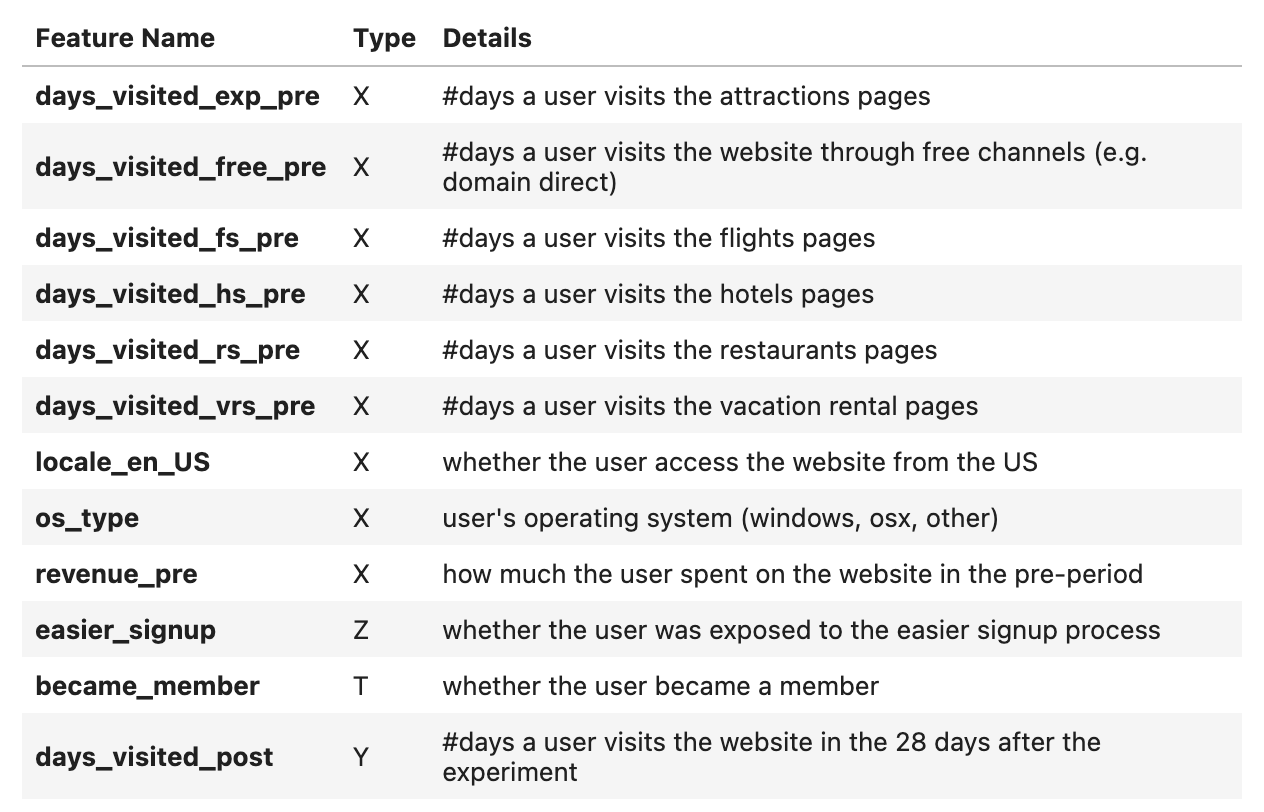

In [28]:
file_url = "https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/RecommendationAB/ab_sample.csv"
ab_data = pd.read_csv(file_url)

In [29]:
ab_data.head()

,days_visited_exp_pre,days_visited_free_pre,days_visited_fs_pre,days_visited_hs_pre,days_visited_rs_pre,days_visited_vrs_pre,locale_en_US,revenue_pre,os_type_osx,os_type_windows,easier_signup,became_member,days_visited_post
0,1,9,7,25,6,3,1,0.01,0,1,0,0,1
1,10,25,27,10,27,27,0,2.26,0,0,0,0,15
2,18,14,8,4,5,2,1,0.03,0,1,0,0,17
3,17,0,23,2,3,1,1,418.77,0,1,0,0,6
4,24,9,22,2,3,18,1,1.54,0,0,0,0,12


In [30]:
Z = ab_data['easier_signup'] # nudge, or instrument
T = ab_data['became_member'] # intervention, or treatment
Y = ab_data['days_visited_post'] # outcome of interest
X_data = ab_data.drop(columns=['easier_signup', 'became_member', 'days_visited_post']) # features

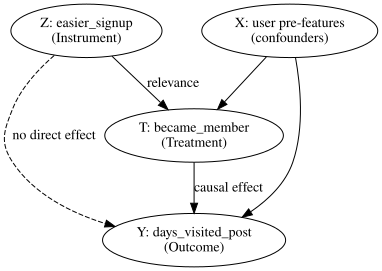

In [31]:
from graphviz import Digraph

dot = Digraph(comment='Instrumental Variable DAG')

# Nodes
dot.node('Z', 'Z: easier_signup\n(Instrument)')
dot.node('T', 'T: became_member\n(Treatment)')
dot.node('Y', 'Y: days_visited_post\n(Outcome)')
dot.node('X', 'X: user pre-features\n(confounders)')

# Edges
dot.edge('Z', 'T', label='relevance')
dot.edge('T', 'Y', label='causal effect')

dot.edge('X', 'T')
dot.edge('X', 'Y')

# Exclusion restriction (optional, dashed)
dot.edge('Z', 'Y', style='dashed', label='no direct effect')

dot


### 가정 체크

- Relevance: signup을 해야지만, member가 될 수 있기 때문에 Z는 효과적인 도구변수이다. 이를 현실적으로 수치로도 확인해볼 수 있다.
- Independence: easier_signup은 A/B 실험으로 무작위 배정된 UI 변경이기에 잠재 변수들과 독립일 가능성이 높다.
- Exclusion Restriction (No Direct Effect): UI 변경이 방문일수를 직접적으로 바꾸지는 않는다.
- Monotonicity: signup을 쉽게 만들었는데 오히려 회원가입을 포기할 사람은 거의 없을 것이다.

In [32]:
# Relevance

print("P(T=1|Z=1) =", T[Z==1].mean())
print("P(T=1|Z=0) =", T[Z==0].mean())
print("Diff =", T[Z==1].mean() - T[Z==0].mean())

P(T=1|Z=1) = 0.6978538028056432
P(T=1|Z=0) = 0.005965010608911485
Diff = 0.6918887921967317


## Modeling

### Wald Estimate 

- Linear Regression을 통해 추정 가능하다:

    $$
    \theta
    \;:=\;
    \frac{
    \mathbb{E}_{X}\!\left[
    \mathbb{E}\!\left[\,Y \mid Z=1, X\,\right]
    -
    \mathbb{E}\!\left[\,Y \mid Z=0, X\,\right]
    \right]
    }{
    \mathbb{E}_{X}\!\left[
    \mathbb{E}\!\left[\,T \mid Z=1, X\,\right]
    -
    \mathbb{E}\!\left[\,T \mid Z=0, X\,\right]
    \right]
    }.
    $$


In [35]:
XZ = pd.concat([Z, X_data], axis=1)

model_y = LinearRegression()
model_y.fit(XZ, Y)

model_t = LogisticRegression(
    solver="liblinear",
    max_iter=5000
)
model_t.fit(XZ, T)

XZ_1 = XZ.copy()
XZ_1['easier_signup'] = 1

XZ_0 = XZ.copy()
XZ_0['easier_signup'] = 0

num = np.mean(model_y.predict(XZ_1) - model_y.predict(XZ_0))

den = np.mean(
    model_t.predict_proba(XZ_1)[:, 1]
    - model_t.predict_proba(XZ_0)[:, 1]
)

theta = num / den
theta

np.float64(2.4303712760282243)

### LinearIntentToTreatDRIV

- 식을 DoublyRobust하게 뽑을 수 있으며, ML도 결합하여 사용할 수 있다.

In [13]:
lgb_T_XZ_params = {
    'objective' : 'binary',
    'metric' : 'auc',
    'learning_rate': 0.1,
    'num_leaves' : 30,
    'max_depth' : 5
}

lgb_Y_X_params = {
    'metric' : 'rmse',
    'learning_rate': 0.1,
    'num_leaves' : 30,
    'max_depth' : 5
}
model_T_XZ = lgb.LGBMClassifier(**lgb_T_XZ_params)
model_Y_X = lgb.LGBMRegressor(**lgb_Y_X_params)
flexible_model_effect = lgb.LGBMRegressor(**lgb_Y_X_params)

In [14]:
model = LinearIntentToTreatDRIV(
    model_y_xw = model_Y_X,
    model_t_xwz = model_T_XZ,
    flexible_model_effect = flexible_model_effect,
    featurizer = PolynomialFeatures(degree=1, include_bias=False)
)
model.fit(Y, T, Z=Z, X=X_data, inference="statsmodels")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 10
[LightGBM] [Info] Start training from score 9.952170
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have vali

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 10
[LightGBM] [Info] Start training from score 2.718645
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 66666, number of used features: 10
[LightGBM] [Info] Start training from score 9.937464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

...

/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have vali

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 66667, number of used features: 10
[LightGBM] [Info] Start training from score 9.939700
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have vali

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 66667, number of used features: 10
[LightGBM] [Info] Start training from score 2.706137
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jhkim/miniconda3/envs/scpi-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have vali

In [41]:
late = model.ate(X=X_data)
late_ci = model.ate_interval(X=X_data)
print("IV-based mean effect (LATE avg over X):", late)
print("CI:", late_ci)


IV-based mean effect (LATE avg over X): 2.0445852355071112
CI: (np.float64(1.9336189424389112), np.float64(2.1555515285753115))


#### CATE

In [42]:
coef_indices = np.arange(model.coef_.shape[0])
coef_error = np.asarray(model.coef__interval())
coef_error[0, :] = model.coef_ - coef_error[0, :]
coef_error[1, :] = coef_error[1, :] - model.coef_

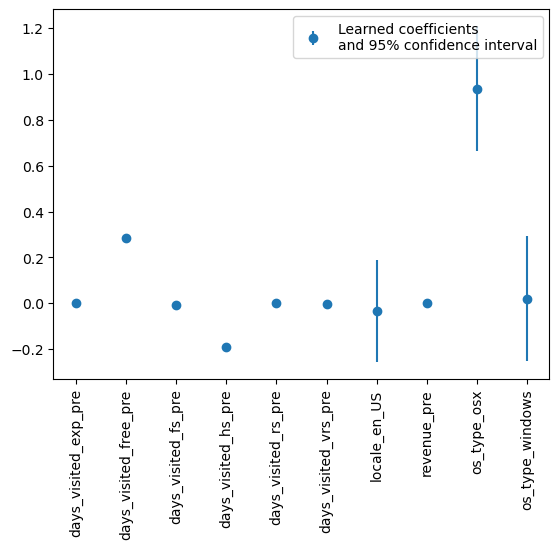

In [43]:
plt.errorbar(coef_indices, model.coef_, coef_error, fmt="o", label="Learned coefficients\nand 95% confidence interval")
plt.xticks(coef_indices, X_data.columns, rotation='vertical')
plt.legend()
plt.show()

In [44]:
model.summary()

,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
days_visited_exp_pre,0.001,0.007,0.162,0.871,-0.012,0.014
days_visited_free_pre,0.285,0.007,38.287,0.0,0.27,0.299
days_visited_fs_pre,-0.008,0.007,-1.165,0.244,-0.021,0.005
days_visited_hs_pre,-0.19,0.007,-28.112,0.0,-0.203,-0.177
days_visited_rs_pre,0.001,0.007,0.112,0.91,-0.012,0.014
days_visited_vrs_pre,-0.001,0.007,-0.211,0.833,-0.015,0.012
locale_en_US,-0.034,0.113,-0.303,0.762,-0.256,0.188
revenue_pre,-0.0,0.0,-0.926,0.354,-0.0,0.0
os_type_osx,0.935,0.139,6.731,0.0,0.662,1.207
os_type_windows,0.021,0.138,0.15,0.881,-0.251,0.292


각 계수의 해석이 가능하다:
“이 변수가 1만큼 증가하면, ‘회원이 되었을 때의 효과’가 얼마나 변하는가?”

e.g. days_visited_free_pre = +0.285 (매우 유의) -> free 콘텐츠를 많₩이 쓰던 유저일수록 회원가입 채널을 쉽게 바꿨을때의 효과가 크게 증가